In [3]:
import torch
from hpc.layers import SparseLayer
from hpc.models import PatternAssociator, PATrainer, SparseHopfieldNetwork, AutoEncoder
import pcn
from pcn.models import PCModel
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from hpc import utils
import numpy as np
from scipy import stats
import torch.nn.functional as F
from pcn import plotting
from hpc.hopfield_network_utils import *

In [1]:
n_ec = 300
p = n_ec/(1.1*10**5)
n_dg = round(1.2*10**6*p)
n_ca3 = round(2.5*10**5*p)
n_ca1 = round(3.9*10**5*p)

In [2]:
n_dg, n_ca3, n_ca1

(3273, 682, 1064)

In [4]:
dataset_name = 'mnist'
size = (1, 28, 28)
N_patterns = 64

train_dataset = torch.load(f'./data/{dataset_name}_train.pt')
img = train_dataset['img'][-N_patterns:]
ec = train_dataset['ec'][-N_patterns:]

C:\Users\lucfonta\AppData\Local\Temp\ipykernel_33208\613239596.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_dataset = torch.load(f'./data/{dataset_name}_train.p

In [5]:
mnist_patterns = {'img': img, 'ec': ec}

In [6]:
pcn.utils.seed(0)
g = torch.Generator()
g.manual_seed(0)

In [7]:
seed = 0

# dataset params
train_size = None
test_size = None
normalize = True
batch_size = 64

# inference params
mu_dt = 0.01
n_test_iters = 200
n_max_iters = 20000
step_tolerance = 1e-5
init_std = 0.01
fixed_preds_test = False

# model params
use_bias = True
kaiming_init = False
n_ec = 300
act_fn = "tanh"
kaiming = False
if dataset_name == 'mnist':
    n_vc = 550
elif dataset_name  == 'fmnist':
    n_vc = 750
else:
    n_vc = 2000

nodes = [n_ec, n_vc, np.prod(size)]
    
model_name = f"pcn-{dataset_name}-n_vc={n_vc}-n_ec={n_ec}" 
pcmodel = PCModel(
    nodes=nodes, mu_dt=mu_dt, act_fn=act_fn, use_bias=use_bias, kaiming_init=kaiming_init
)
pcmodel.load_state_dict(torch.load(f"../unsupervised-pcn/models/{model_name}.pt", map_location=pcn.utils.DEVICE, weights_only=True))

<All keys matched successfully>

## EC-DG-CA3

In [8]:
act_fn1 = "relu"
_act_fn1 = torch.relu
EC_DG = SparseLayer(
    in_size=n_ec, 
    out_size=n_dg, 
    act_fn=_act_fn1,
    c=1,
    f=0.01,
    device=torch.device('cpu')
)
# torch.save(EC_DG.state_dict(), f'models/EC_DG_{act_fn1}_sparse.pt')
EC_DG.load_state_dict(torch.load(f'models/EC_DG_{act_fn1}_sparse.pt', weights_only=True))


act_fn2 = "heaviside"
_act_fn2 = torch.heaviside
DG_CA3 = SparseLayer(
    in_size=n_dg,
    out_size=n_ca3, 
    act_fn=_act_fn2,
    c=1,
    f=0.06,
    device=torch.device('cpu')
)
# torch.save(DG_CA3.state_dict(), f'models/DG_CA3_{act_fn2}_sparse.pt')
DG_CA3.load_state_dict(torch.load(f'models/DG_CA3_{act_fn2}_sparse.pt', weights_only=True))

<All keys matched successfully>

In [9]:
with torch.no_grad():
    dg = EC_DG(ec)
    ca3 = DG_CA3(dg)

In [25]:
mnist_patterns['ca3'] = ca3
torch.save(mnist_patterns, f'./data/{dataset_name}_patterns.pt')

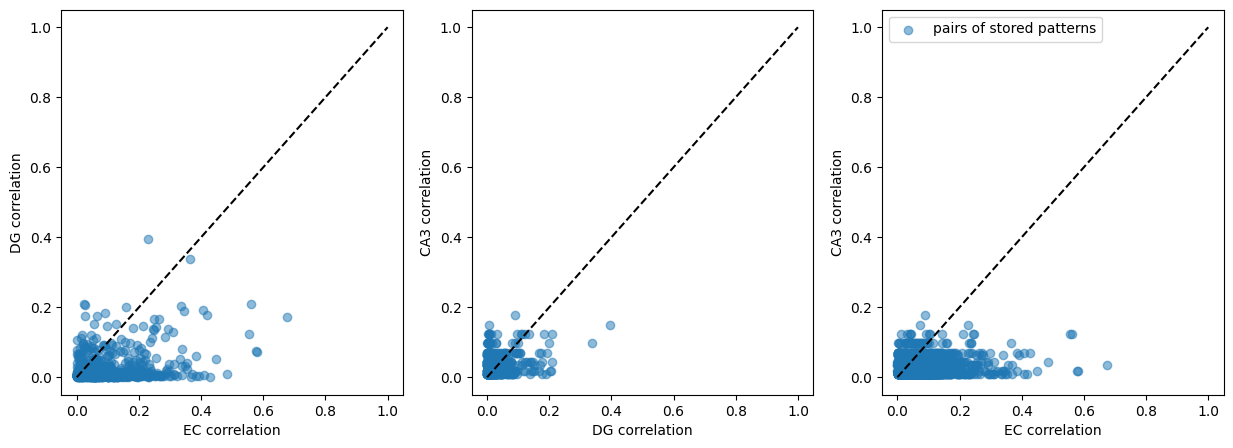

In [26]:
activities = [ec, dg, ca3]

n_plots = len(activities)
n_samples = N_patterns
corr = torch.zeros((n_plots, n_samples*(n_samples-1)//2))
cos = torch.zeros((n_plots, n_samples*(n_samples-1)//2))
indices = torch.triu_indices(n_samples, n_samples, offset=1)

for i in range (n_plots):
    x = activities[i]   
    R = torch.corrcoef(x).abs()
    corr[i] = R[indices[0], indices[1]]

layers = ['EC', 'DG', 'CA3']
fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 5))

for i in range(n_plots - 1):
    axes[i].scatter(corr[i], corr[i+1], alpha=0.5)
    axes[i].plot([0, 1], [0, 1], 'k--')
    axes[i].set_xlabel(f'{layers[i]} correlation')
    axes[i].set_ylabel(f'{layers[i+1]} correlation')

axes[n_plots - 1].scatter(corr[0], corr[n_plots - 1], alpha=0.5, label="pairs of stored patterns")
axes[n_plots - 1].plot([0, 1], [0, 1], 'k--')
axes[n_plots - 1].set_xlabel(f'{layers[0]} correlation')
axes[n_plots - 1].set_ylabel(f'{layers[n_plots - 1]} correlation')
axes[n_plots - 1].legend()

(array([43656.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,  2720.]),
 array([0.        , 0.1       , 0.2       , 0.30000001, 0.40000001,
        0.5       , 0.60000002, 0.69999999, 0.80000001, 0.90000004,
        1.        ]),
 <BarContainer object of 10 artists>)

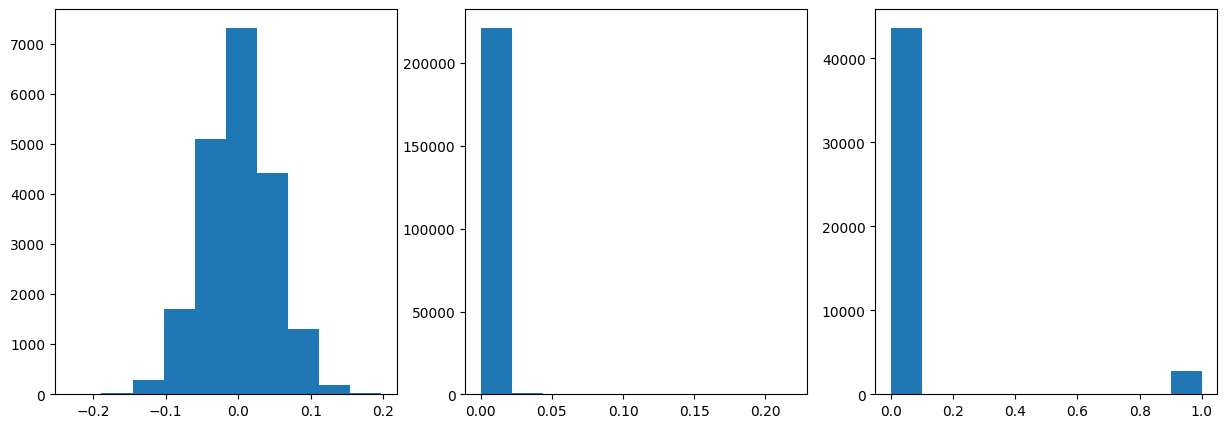

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].hist(ec.flatten())
axes[1].hist(dg.flatten())
axes[2].hist(ca3.flatten())

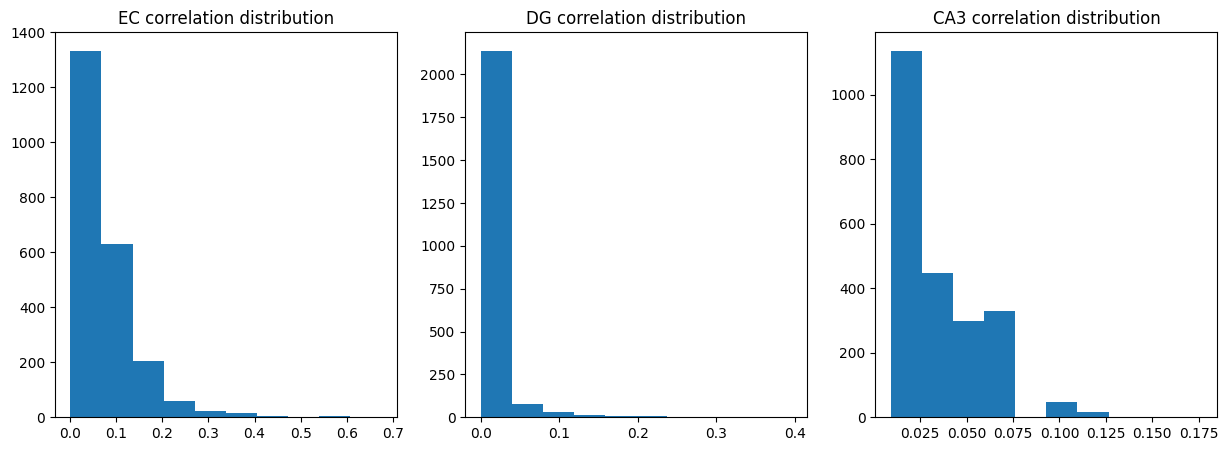

In [8]:
fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 5))
for i in range(n_plots):
    axes[i].hist(corr[i])
    axes[i].set_title(f'{layers[i]} correlation distribution')

Text(0, 0.5, 'Number of pairs')

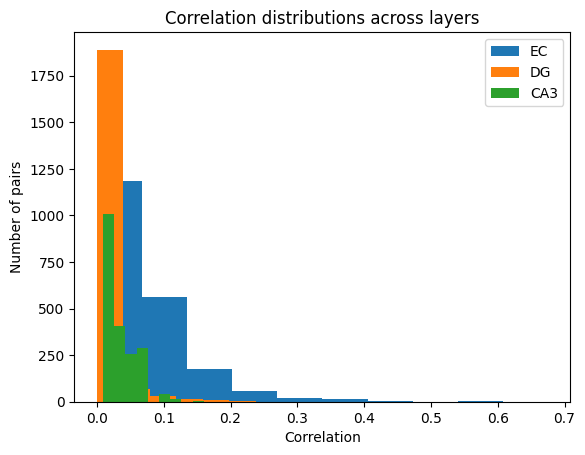

In [27]:
for i in range(n_plots):
    plt.hist(corr[i], label=f'{layers[i]}')
plt.legend()
plt.title('Correlation distributions across layers')
plt.xlabel('Correlation')
plt.ylabel('Number of pairs')

## EC-CA3

### Training

In [28]:
pcn.utils.seed(0)
g = torch.Generator()
g.manual_seed(0)
tensor_dataset = TensorDataset(ec, ca3)
train_loader = DataLoader(
    tensor_dataset, 
    batch_size=1, 
    shuffle=True, 
    worker_init_fn=pcn.utils.seed_worker, 
    generator=g
)

pcn.utils.seed(0)
g = torch.Generator()
g.manual_seed(0)
test_loader = DataLoader(
    tensor_dataset, 
    batch_size=1, 
    shuffle=True, 
    worker_init_fn=pcn.utils.seed_worker, 
    generator=g # same order as for train_loader
)  

In [29]:
lrs = sorted([2*i/10**(4-j) for i in range(1, 5) for j in range(7)])

In [10]:
lrs

[0.0002,
 0.0004,
 0.0006,
 0.0008,
 0.002,
 0.004,
 0.006,
 0.008,
 0.02,
 0.04,
 0.06,
 0.08,
 0.2,
 0.4,
 0.6,
 0.8,
 2.0,
 4.0,
 6.0,
 8.0,
 20.0,
 40.0,
 60.0,
 80.0,
 200.0,
 400.0,
 600.0,
 800.0]

In [30]:
ec_mean = train_dataset['ec'].mean(dim=0)

In [31]:
n_seeds = 10
n_epochs = 10
errors = utils.best_lr(
    lrs=lrs, 
    train_loader=train_loader, 
    test_loader=test_loader, 
    in_size=n_ec, 
    out_size=n_ca3,
    act_fn=torch.heaviside, 
    in_mean=ec_mean, 
    use_bias=True, 
    f=0.06,
    glorot_init=True,
    n_epochs=n_epochs,
    n_seeds=n_seeds
)

100%|██████████| 10/10 [02:13<00:00, 13.32s/it]


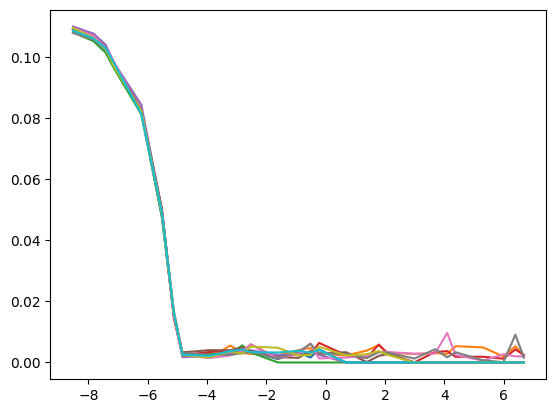

In [32]:
n_seeds = len(errors)
for seed in range(n_seeds):
    plt.plot(np.log(lrs), errors[seed])

In [33]:
mean_error = errors.mean(dim=0)
std_error = errors.std(dim=0, unbiased=False)

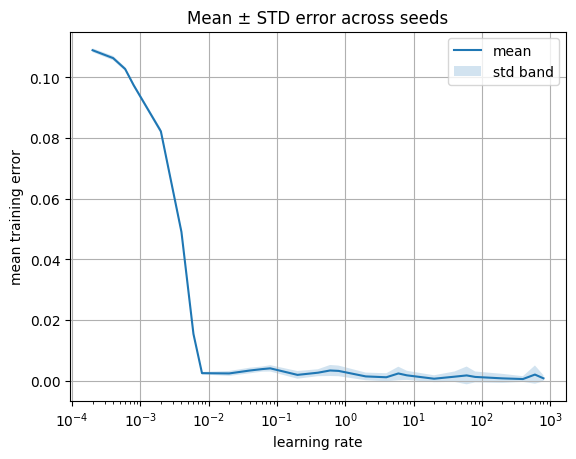

In [34]:
plt.plot(lrs, mean_error)
plt.fill_between(lrs, mean_error - std_error, mean_error + std_error, alpha=0.2)
plt.xscale('log')
plt.xlabel('learning rate')
plt.ylabel('mean training error')
plt.title('Mean ± STD error across seeds')
plt.grid(True)
plt.legend(['mean', 'std band'])

In [36]:
lrs

[0.0002,
 0.0004,
 0.0006,
 0.0008,
 0.002,
 0.004,
 0.006,
 0.008,
 0.02,
 0.04,
 0.06,
 0.08,
 0.2,
 0.4,
 0.6,
 0.8,
 2.0,
 4.0,
 6.0,
 8.0,
 20.0,
 40.0,
 60.0,
 80.0,
 200.0,
 400.0,
 600.0,
 800.0]

In [35]:
i = mean_error.argmin()
lr = lrs[i]
print(lr, mean_error[i])

400.0 tensor(0.0006)


In [14]:
mean_error

tensor([0.1088, 0.1062, 0.1025, 0.0974, 0.0826, 0.0495, 0.0161, 0.0026, 0.0028,
        0.0038, 0.0044, 0.0038, 0.0024, 0.0027, 0.0041, 0.0041, 0.0020, 0.0019,
        0.0032, 0.0034, 0.0021, 0.0018, 0.0037, 0.0026, 0.0020, 0.0017, 0.0034,
        0.0027])

In [36]:
model = PatternAssociator(
    in_size=n_ec, 
    in_mean=ec_mean,
    out_size=n_ca3, 
    act_fn=torch.heaviside, 
    use_bias=True, 
    c=1, 
    f=0.06, 
    glorot_init=True
)
optimizer = pcn.optim.get_optim(
            [model.layer],
            "SGD",
            lr,
            batch_scale=True,
            grad_clip=None,
            weight_decay=None
        )
trainer = PATrainer(model, optimizer)

Epoch 1/10
All patterns: 0.2083
Last 20 patterns: 0.2577
Epoch 2/10
All patterns: 0.5020
Last 20 patterns: 0.4967
Epoch 3/10
All patterns: 0.7290
Last 20 patterns: 0.7278
Epoch 4/10
All patterns: 0.8954
Last 20 patterns: 0.8978
Epoch 5/10
All patterns: 0.9012
Last 20 patterns: 0.9057
Epoch 6/10
All patterns: 0.9332
Last 20 patterns: 0.9349
Epoch 7/10
All patterns: 0.9871
Last 20 patterns: 0.9907
Epoch 8/10
All patterns: 0.9805
Last 20 patterns: 0.9801
Epoch 9/10
All patterns: 0.9838
Last 20 patterns: 0.9841
Epoch 10/10
All patterns: 0.9876
Last 20 patterns: 0.9907


Text(0, 0.5, 'Correlation')

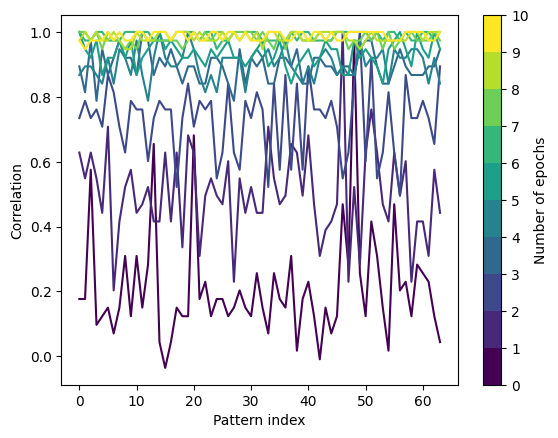

In [37]:
import matplotlib as mpl
n_epochs = 10
cmap = plt.get_cmap('viridis', n_epochs)
fig, ax = plt.subplots()
with torch.no_grad():
    for epoch in range(n_epochs):
        corr = []
        print(f"Epoch {epoch+1}/{n_epochs}")
        trainer.train(train_loader, epoch)
        for inputs, targets in test_loader:
            inputs = pcn.utils.set_tensor(inputs)
            preds = model(inputs)
            corr.append(stats.pearsonr(preds.cpu().squeeze().numpy(), targets.squeeze().numpy())[0])
        ax.plot(corr, color=cmap(epoch))
        print(f"All patterns: {np.mean(corr):.4f}")
        print(f"Last 20 patterns: {np.mean(corr[-20:]):.4f}")

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(0, n_epochs))
plt.colorbar(sm, ax=ax, ticks=np.linspace(0, n_epochs, n_epochs+1), label="Number of epochs")
plt.xlabel('Pattern index')
plt.ylabel('Correlation')


In [38]:
torch.save(model.state_dict(), f'models/EC_CA3_{dataset_name}.pt')

### Inference

In [12]:
model = PatternAssociator(
    in_size=n_ec, 
    in_mean=torch.zeros(1),
    out_size=n_ca3, 
    act_fn=torch.heaviside, 
    use_bias=True, 
    c=1, 
    f=0.06, 
    glorot_init=True
)
model.load_state_dict(torch.load(f'models/EC_CA3_{dataset_name}.pt', weights_only=True))

<All keys matched successfully>

In [13]:
size = (1, 28, 28)
alpha = 0.5
indices = pcn.utils.get_mask_indices(size, alpha)
value = img.mean().item()
img_half = pcn.utils.mask_image(img, indices, value)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8214867].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8214867].


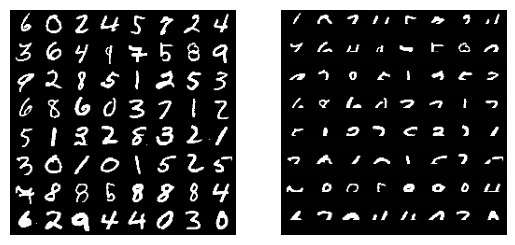

In [41]:
fig, axes = plt.subplots(1, 2)
plotting.plot_samples(axes[0], img)
plotting.plot_samples(axes[1], img_half)

(array([333., 395.,   3.,   6.,   7.,   4.,  10.,   3.,   4.,  19.]),
 array([-0.42421296, -0.09964299,  0.22492698,  0.54949701,  0.87406695,
         1.19863689,  1.52320695,  1.84777689,  2.17234683,  2.49691677,
         2.82148671]),
 <BarContainer object of 10 artists>)

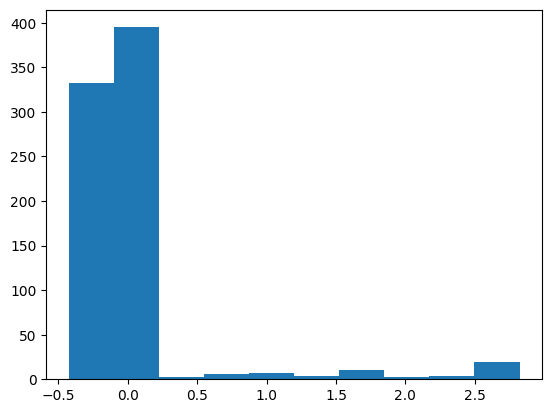

In [27]:
plt.hist(img_half[0])

In [14]:
pcn.utils.seed(0)
g = torch.Generator()
g.manual_seed(0)

with torch.no_grad():
    img_half = pcn.utils.set_tensor(img_half)
    pcmodel.test_batch(
        img_half, 
        n_iters=n_max_iters, 
        step_tolerance=step_tolerance, 
        init_std=init_std, 
        fixed_preds=fixed_preds_test
    )
    ec_half = pcmodel.mus[0]

In [15]:
with torch.no_grad():
    ca3_half = model(ec_half).cpu()

ec_half = ec_half.cpu()

In [44]:
from scipy import stats

recall_corr = np.zeros((N_patterns, 2))
recall_cos = np.zeros((N_patterns, 2))
for i in range(N_patterns):
    recall_corr[i, 0] = stats.pearsonr(ec[i], ec_half[i])[0]
    recall_corr[i, 1] = stats.pearsonr(ca3[i], ca3_half[i])[0]
    recall_cos[i, 0] = F.cosine_similarity(ec[i].unsqueeze(0), ec_half[i].unsqueeze(0)).item()
    recall_cos[i, 1] = F.cosine_similarity(ca3[i].unsqueeze(0), ca3_half[i].unsqueeze(0)).item()

In [45]:
activities = [ec, ca3]
n_plots = len(activities)
n_samples = N_patterns
corr = torch.zeros((n_plots, n_samples*(n_samples-1)//2))
cos = torch.zeros((n_plots, n_samples*(n_samples-1)//2))
indices = torch.triu_indices(n_samples, n_samples, offset=1)

for i in range(n_plots):
    x = activities[i]   
    R = torch.corrcoef(x).abs()
    corr[i] = R[indices[0], indices[1]]
    R = F.cosine_similarity(x[None,:,:], x[:,None,:], dim=-1)
    cos[i] = R[indices[0], indices[1]]

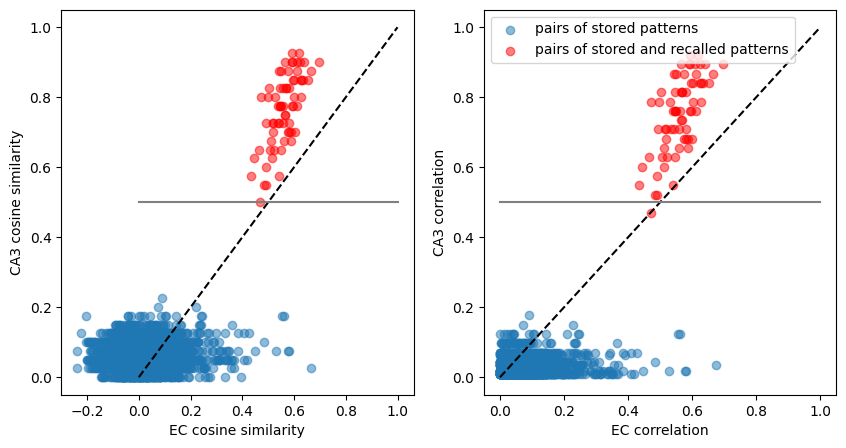

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(5*2, 5))

axes[0].scatter(cos[0], cos[1], alpha=0.5)
axes[0].scatter(recall_cos[:, 0], recall_cos[:, 1], color='red', alpha=0.5)
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_xlabel('EC cosine similarity')
axes[0].set_ylabel('CA3 cosine similarity')
axes[0].plot([0, 1], [0.5, 0.5], 'gray')

axes[1].scatter(corr[0], corr[1], alpha=0.5, label="pairs of stored patterns")
axes[1].scatter(recall_corr[:, 0], recall_corr[:, 1], color='red', alpha=0.5, label="pairs of stored and recalled patterns")
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlabel(f'EC correlation')
axes[1].set_ylabel(f'CA3 correlation')
axes[1].plot([0, 1], [0.5, 0.5], 'gray')
axes[1].legend()

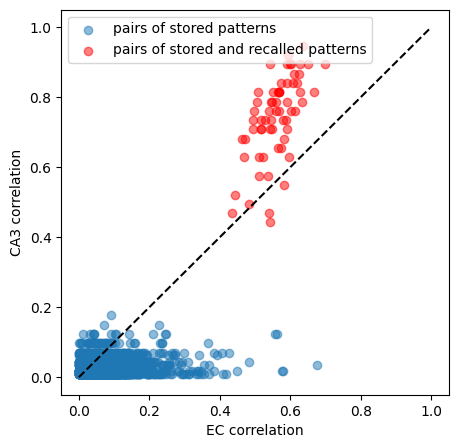

In [46]:
plt.figure(figsize=(5, 5))
plt.scatter(corr[0], corr[1], alpha=0.5, label="pairs of stored patterns")
plt.scatter(recall_corr[:, 0], recall_corr[:, 1], color='red', alpha=0.5, label="pairs of stored and recalled patterns")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel(f'EC correlation')
plt.ylabel(f'CA3 correlation')
#plt.plot([0, 1], [0.5, 0.5], 'gray')
plt.legend(loc="upper left")

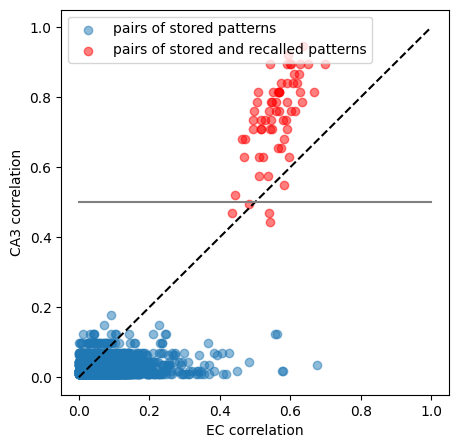

In [54]:
plt.figure(figsize=(5, 5))
plt.scatter(corr[0], corr[1], alpha=0.5, label="pairs of stored patterns")
plt.scatter(recall_corr[:, 0], recall_corr[:, 1], color='red', alpha=0.5, label="pairs of stored and recalled patterns")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel(f'EC correlation')
plt.ylabel(f'CA3 correlation')
plt.plot([0, 1], [0.5, 0.5], 'gray')
plt.legend(loc="upper left")

In [88]:
sorted_idx = [np.argsort(recall_cos[:, 0]), np.argsort(recall_cos[:, 1])]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8214867].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8214867].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8214867].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8214867].


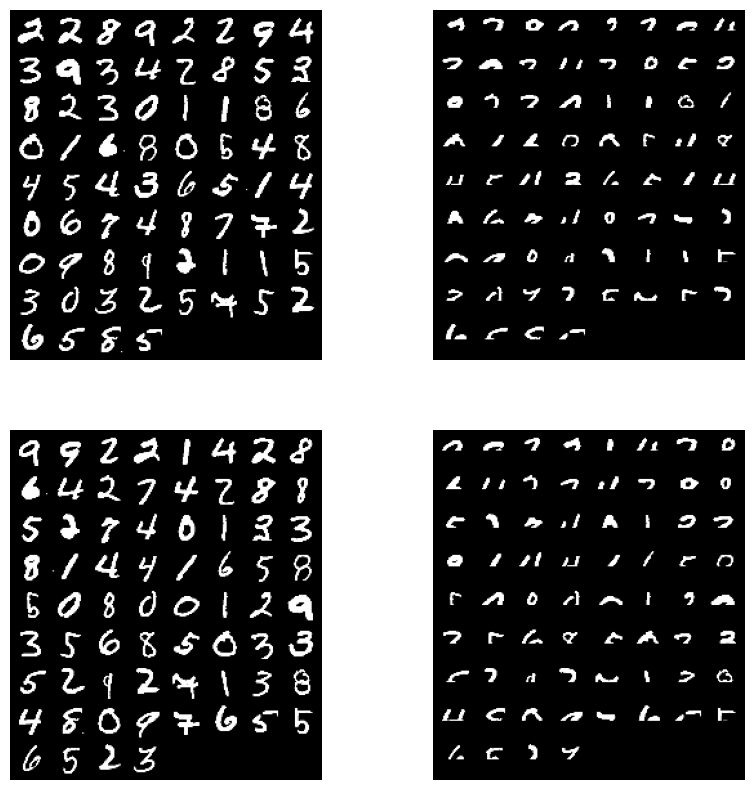

In [89]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for i in range(2):
    plotting.plot_samples(axes[i, 0], img[sorted_idx[i]])
    plotting.plot_samples(axes[i, 1], img_half[sorted_idx[i]])

All patterns: Corr:1.0000, MSE: 0.0000
Last 20 patterns: Corr:1.0000, MSE: 0.0000


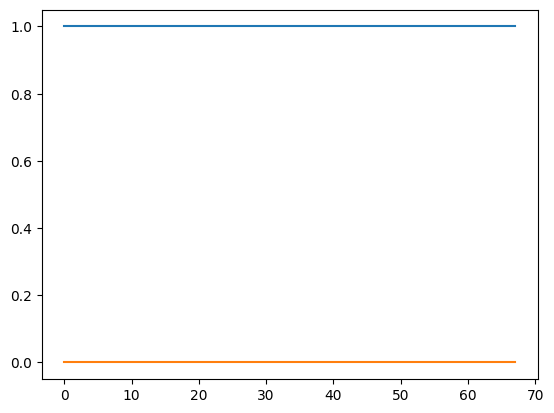

In [72]:
corr = []
err = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = pcn.utils.set_tensor(inputs)
        preds = model(inputs)
        corr.append(stats.pearsonr(preds.cpu().squeeze().numpy(), targets.squeeze().numpy())[0])
        err.append(F.mse_loss(preds.cpu(), targets).item())
plt.plot(corr)
plt.plot(err)
print(f"All patterns: Corr:{np.mean(corr):.4f}, MSE: {np.mean(err):.4f}")
print(f"Last 20 patterns: Corr:{np.mean(corr[-20:]):.4f}, MSE: {np.mean(err[-20:]):.4f}")

In [46]:
np.sort(corr)

array([0.9999998 , 0.9999999 , 0.9999999 , 0.99999994, 0.99999994,
       0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994,
       0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994,
       0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994,
       0.99999994, 0.99999994, 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        ], dtype=float32)

In [43]:
np.argsort(corr)

array([54, 14, 40,  2, 15, 20, 11,  7, 25, 26, 27, 29, 30, 37, 18, 19, 36,
       56, 63, 46, 35, 67,  5,  4, 12, 13,  9, 10,  8,  3,  1,  6, 31, 28,
       24, 17, 16, 21, 22, 23, 39, 38, 42, 41, 43, 33, 34, 32, 47, 45, 44,
       48, 51, 52, 50, 49, 55, 53, 58, 57, 59, 60, 61,  0, 62, 64, 65, 66])

In [103]:
sorted_idx[1]

array([19,  2,  6, 25, 37, 64, 61, 53, 60,  7, 21, 33, 63, 35, 57, 22, 26,
        3,  9, 11, 67, 24, 38, 32, 56, 43,  1, 14, 46,  4, 36, 54, 55, 65,
       58, 31, 47, 34, 10, 62, 66,  8, 13, 29, 23, 45, 44, 41, 49, 50, 15,
       39, 52, 48, 27, 18, 59, 40,  5, 20, 16, 30, 51, 17, 28,  0, 42, 12])

In [90]:
recall_corr[sorted_idx[1]][:, 1]

array([0.46884736, 0.52196264, 0.52196264, 0.54852027, 0.54852027,
       0.57507783, 0.60163552, 0.60163546, 0.60163552, 0.62819314,
       0.6281932 , 0.65475076, 0.65475076, 0.65475076, 0.65475076,
       0.68130839, 0.68130839, 0.68130845, 0.68130851, 0.68130845,
       0.68130839, 0.70786601, 0.70786601, 0.70786607, 0.70786601,
       0.73442358, 0.73442364, 0.73442358, 0.7344237 , 0.76098132,
       0.76098132, 0.76098132, 0.76098126, 0.76098132, 0.76098132,
       0.76098126, 0.76098126, 0.78753889, 0.78753901, 0.78753895,
       0.78753895, 0.81409651, 0.81409651, 0.81409663, 0.81409651,
       0.81409663, 0.81409657, 0.81409663, 0.84065425, 0.84065419,
       0.84065419, 0.84065425, 0.84065413, 0.84065413, 0.86721188,
       0.86721176, 0.86721176, 0.86721182, 0.86721188, 0.89376944,
       0.89376944, 0.89376944, 0.89376944, 0.89376944, 0.8937695 ,
       0.8937695 , 0.92032713, 0.92032713])

In [91]:
recall_cos[sorted_idx[1]][:, 1]

array([0.5       , 0.55000001, 0.55000001, 0.57499999, 0.57499999,
       0.59999996, 0.625     , 0.625     , 0.62500006, 0.64999998,
       0.64999998, 0.67500001, 0.67500001, 0.67500001, 0.67500001,
       0.69999999, 0.69999999, 0.69999999, 0.70000005, 0.70000005,
       0.70000005, 0.72500002, 0.72500002, 0.72500008, 0.72500008,
       0.75      , 0.75000006, 0.75000006, 0.75000006, 0.77499992,
       0.77499998, 0.77499998, 0.77499998, 0.77499998, 0.77499998,
       0.77500004, 0.77500004, 0.79999995, 0.80000001, 0.80000001,
       0.80000001, 0.82499999, 0.82499999, 0.82500005, 0.82500005,
       0.82500005, 0.82500005, 0.82500005, 0.85000002, 0.85000002,
       0.85000002, 0.85000002, 0.85000002, 0.85000008, 0.87499994,
       0.875     , 0.875     , 0.875     , 0.87500006, 0.89999998,
       0.89999998, 0.89999998, 0.89999998, 0.90000004, 0.90000004,
       0.9000001 , 0.92500001, 0.92500001])

## CA3-CA3

Text(0.5, 0.98, 'These are 64 patterns our network will memorize')

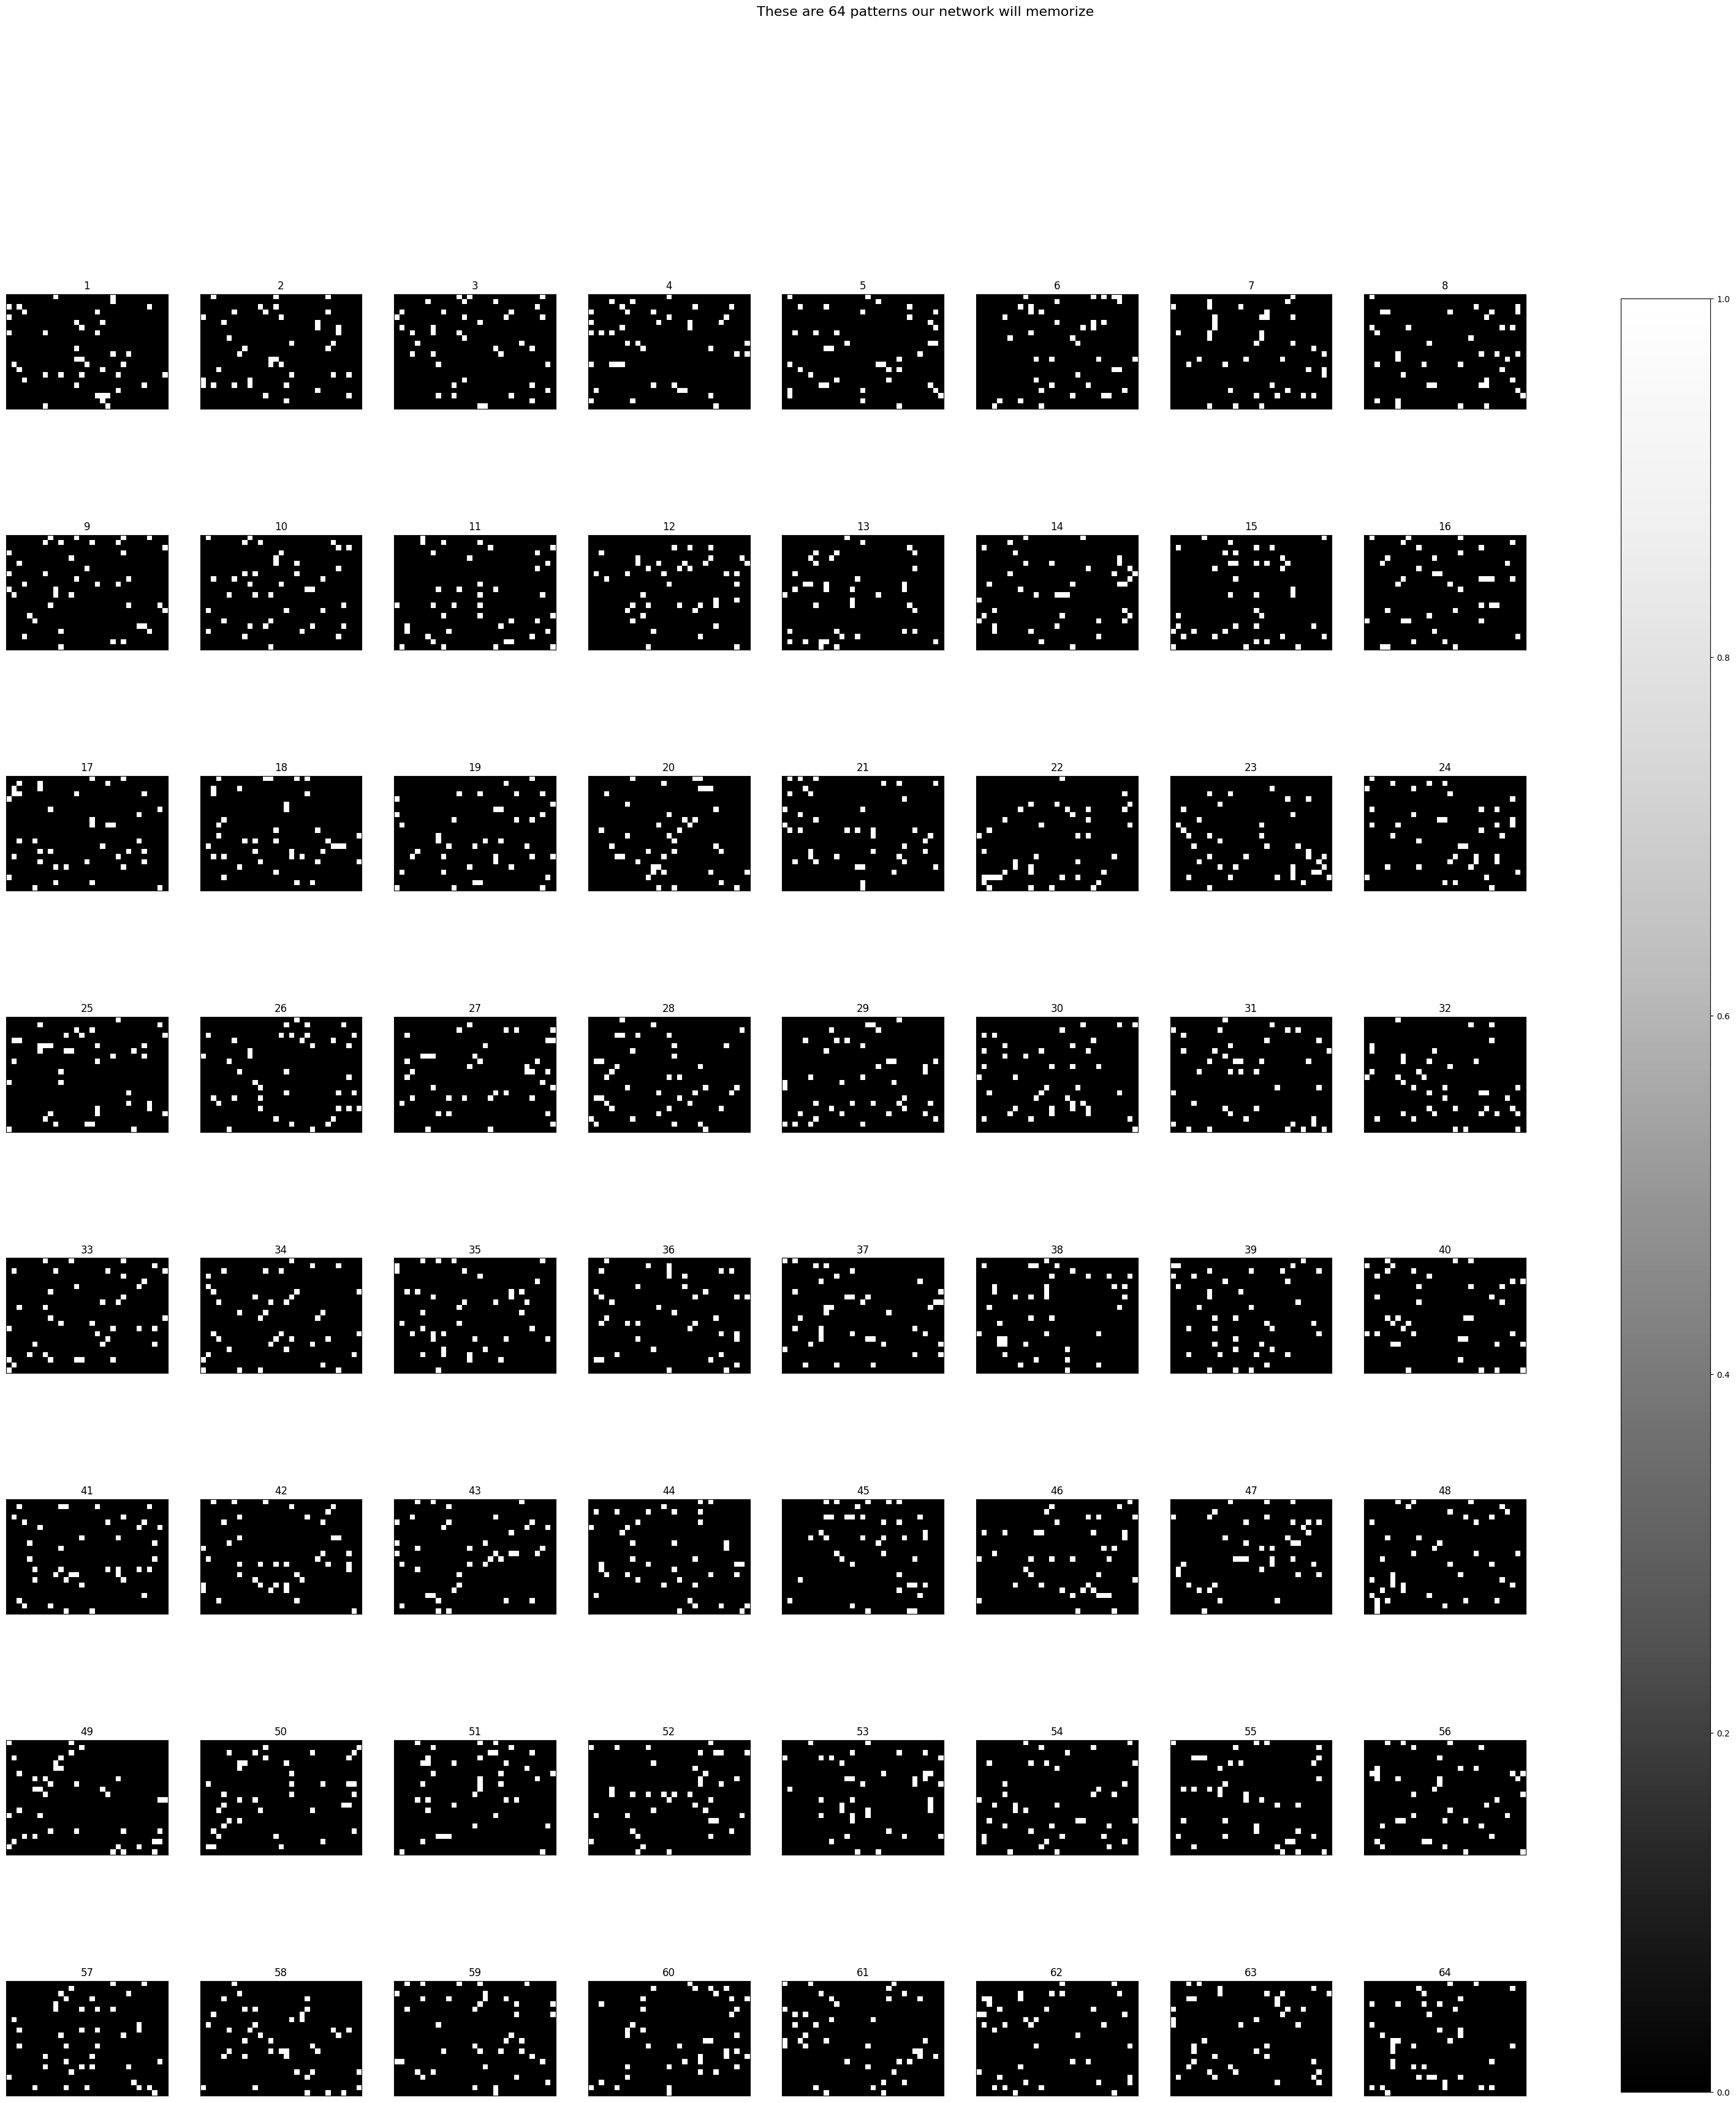

In [10]:
pattern_size = (22, 31)
ca3_patterns = {str(i) : ca3[i-1].reshape(pattern_size).numpy() for i in range(1,N_patterns+1)}
fig, ax = plot_patterns(ca3_patterns)
fig.suptitle(f"These are {ca3_patterns.__len__()} patterns our network will memorize", fontsize=16)

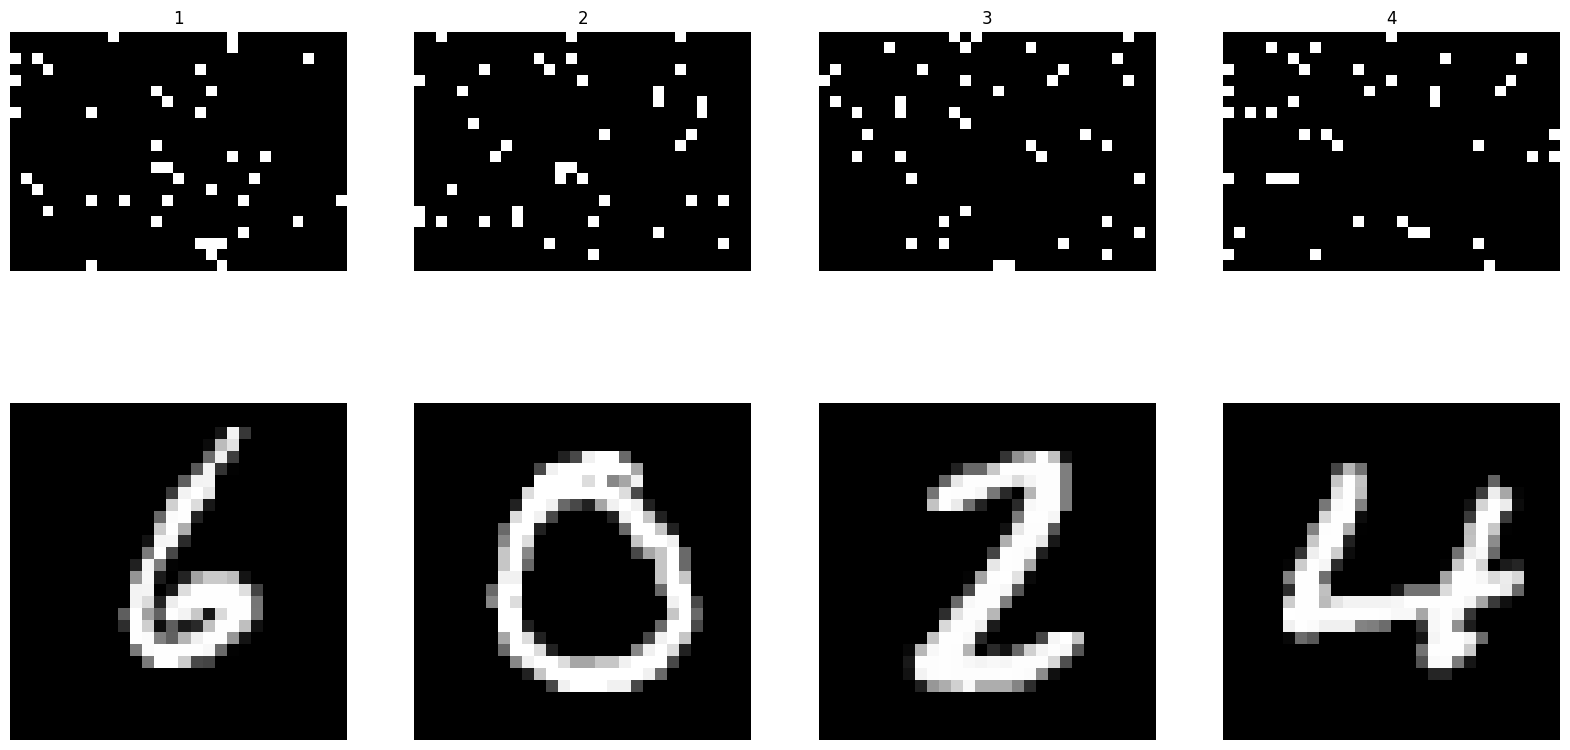

In [48]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i in range(4):
    axes[0, i].set_title(f'{i+1}')
    axes[0, i].imshow(ca3_patterns[str(i+1)], cmap="Greys_r")
    axes[1, i].imshow(img[i].view(size[1], size[2]), cmap="Greys_r")    
    axes[0, i].axis('off')
    axes[1, i].axis('off')

In [49]:
HFN = SparseHopfieldNetwork(ca3_patterns)

In [50]:
pcn.utils.seed(0)
# test ALL the memories and set which ones are unstable
unstable_patterns = []
for pattern in ca3_patterns:
    HFN.set_state(ca3_patterns[pattern].flatten())
    initial_state = copy.deepcopy(HFN.state)
    for i in range(100):
        HFN.update_state(asynchronous=False)
    if not np.all(initial_state == HFN.state): #if a pattern is not stable, add it to the list
        unstable_patterns.append(pattern)

print(f"{100*len(unstable_patterns)/len(ca3_patterns):.1f}% of the memory patterns are unstable. These are {unstable_patterns}")

#visualise an unstable memory
if len(unstable_patterns) > 0:
    HFN.set_state(ca3_patterns[unstable_patterns[1]].flatten()) #reinitialise the state of the network
    HFN.visualise(title=f"Initial state (unstable pattern {unstable_patterns[0]})")
    for i in range(100):
        HFN.update_state(asynchronous=False)
    HFN.visualise(title=f"State after {i+1} updates")

0.0% of the memory patterns are unstable. These are []


Text(0.5, 0.98, 'These are 64 patterns our network will memorize')

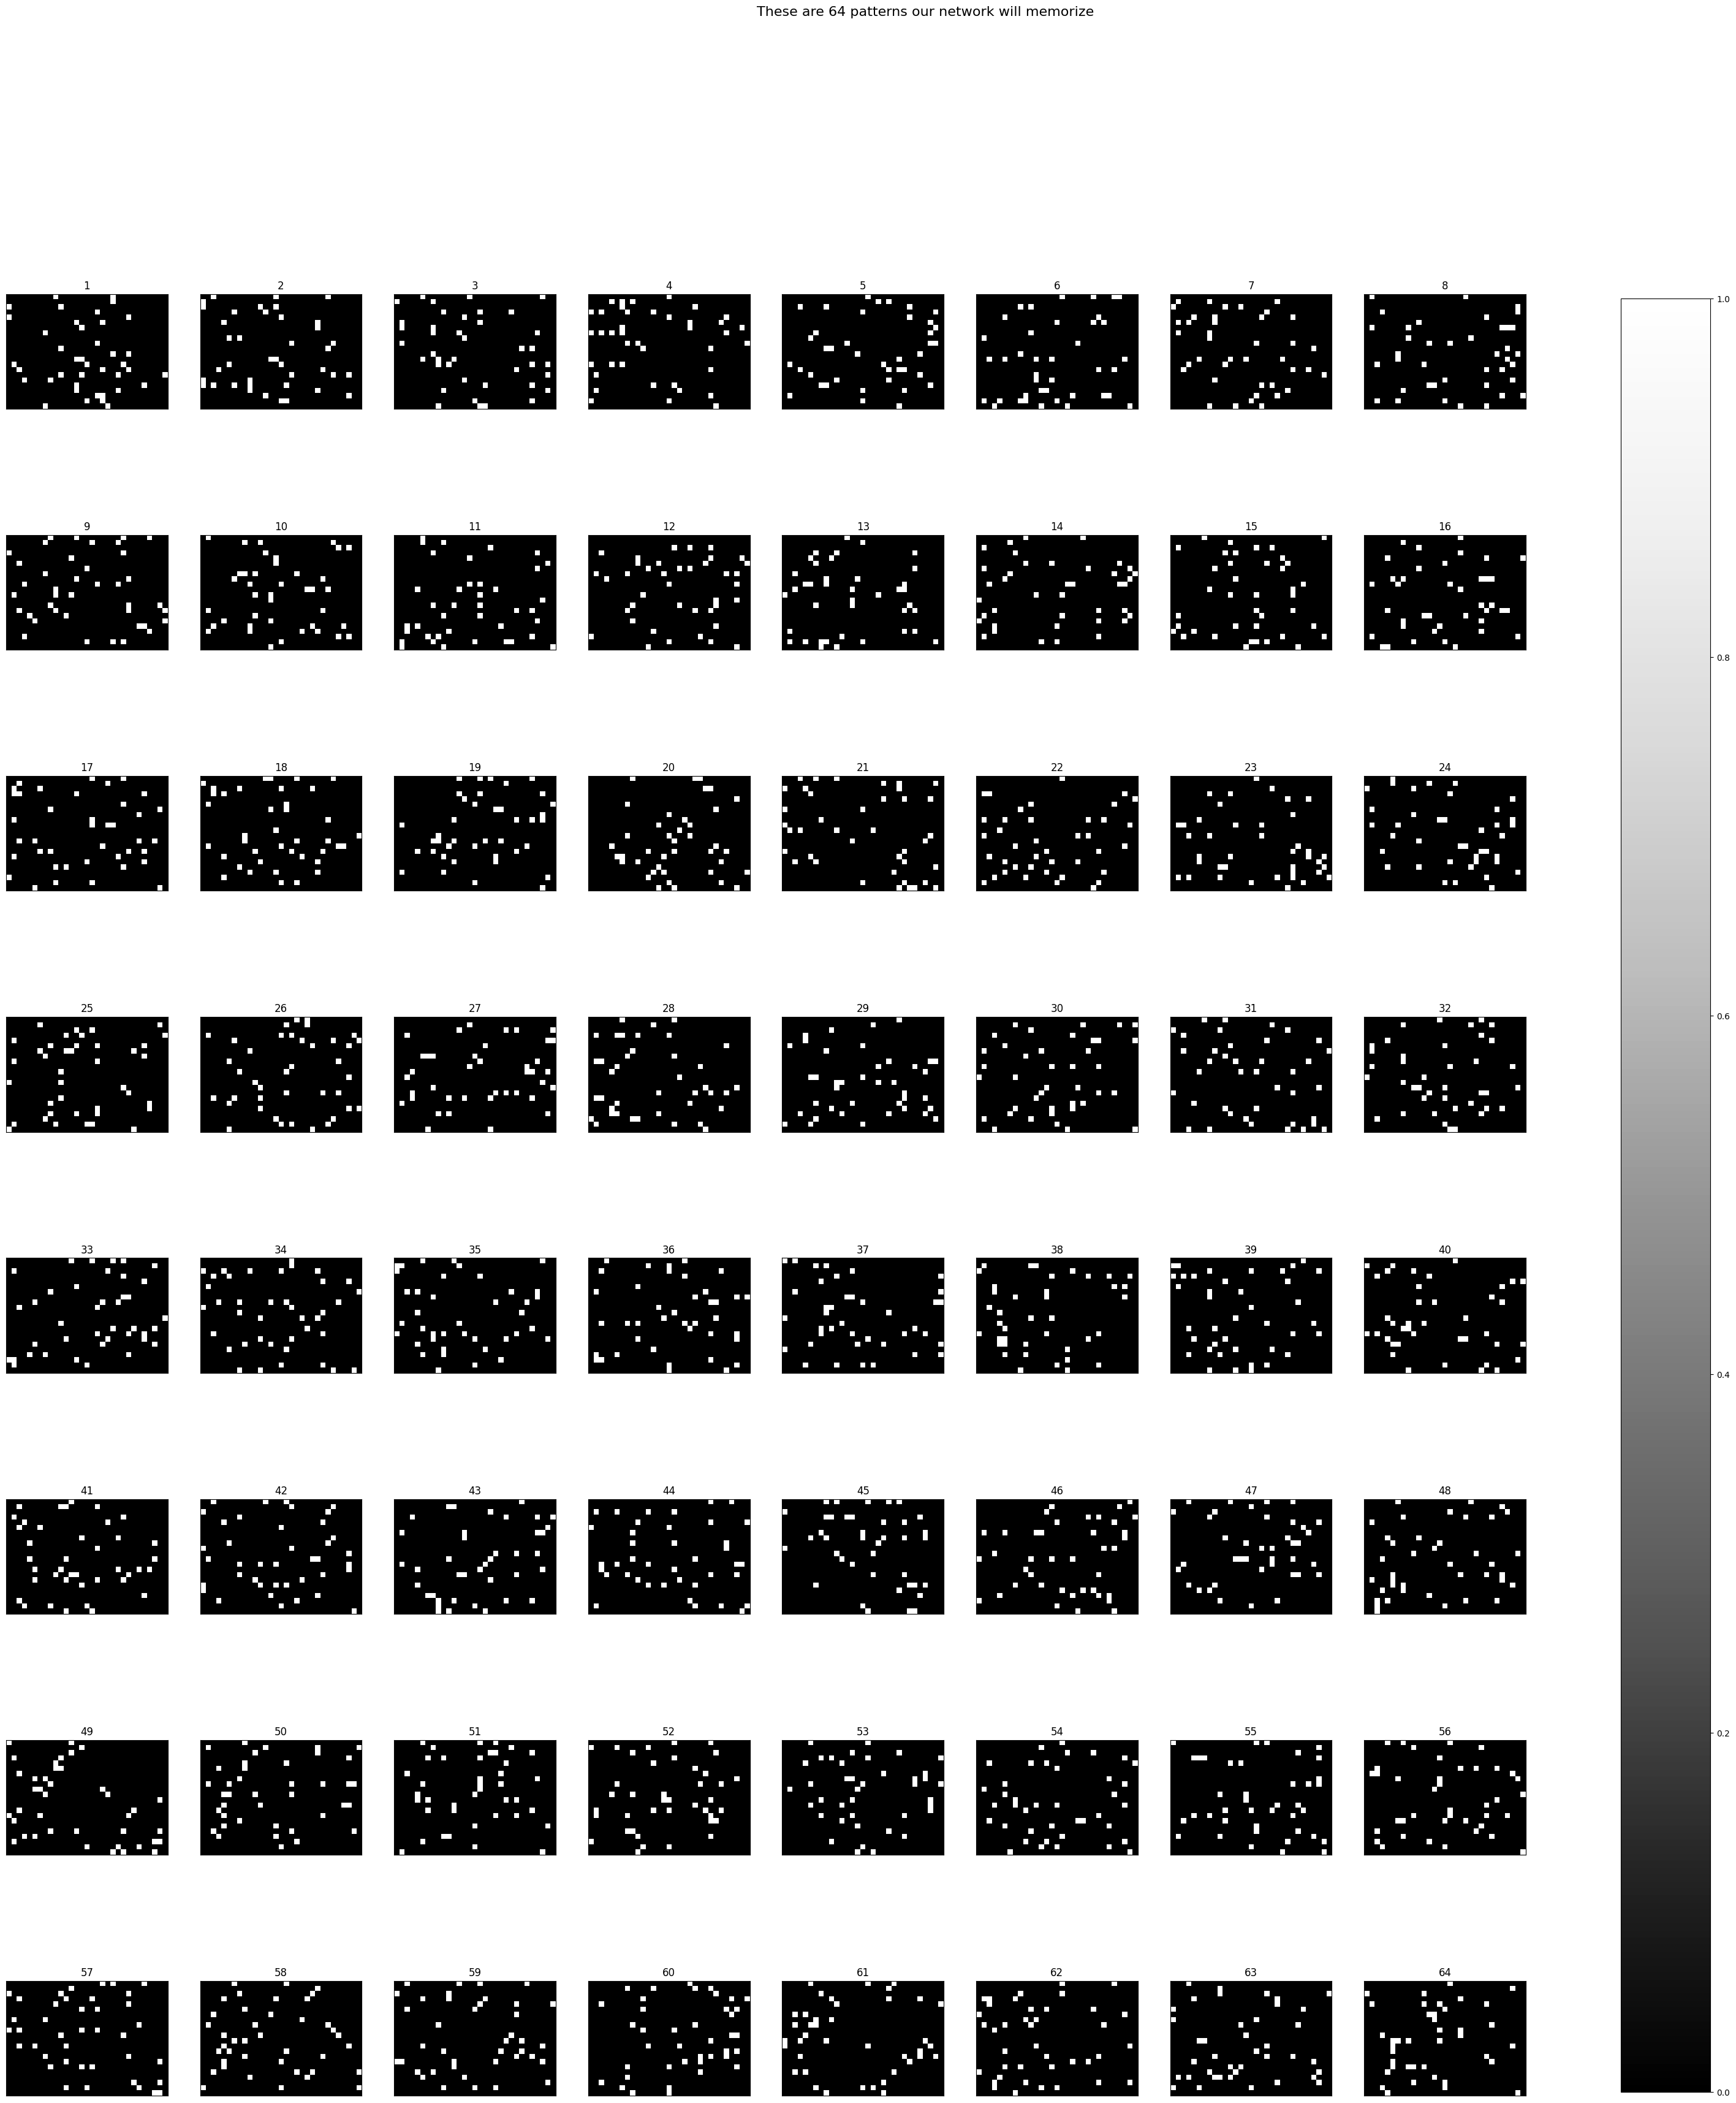

In [16]:
pattern_size = (22, 31)
N_patterns = len(ca3_half)
ca3_half_patterns = {str(i) : ca3_half[i-1].reshape(pattern_size).numpy() for i in range(1,N_patterns+1)}
fig, ax = plot_patterns(ca3_half_patterns)
fig.suptitle(f"These are {ca3_half_patterns.__len__()} patterns our network will memorize", fontsize=16)

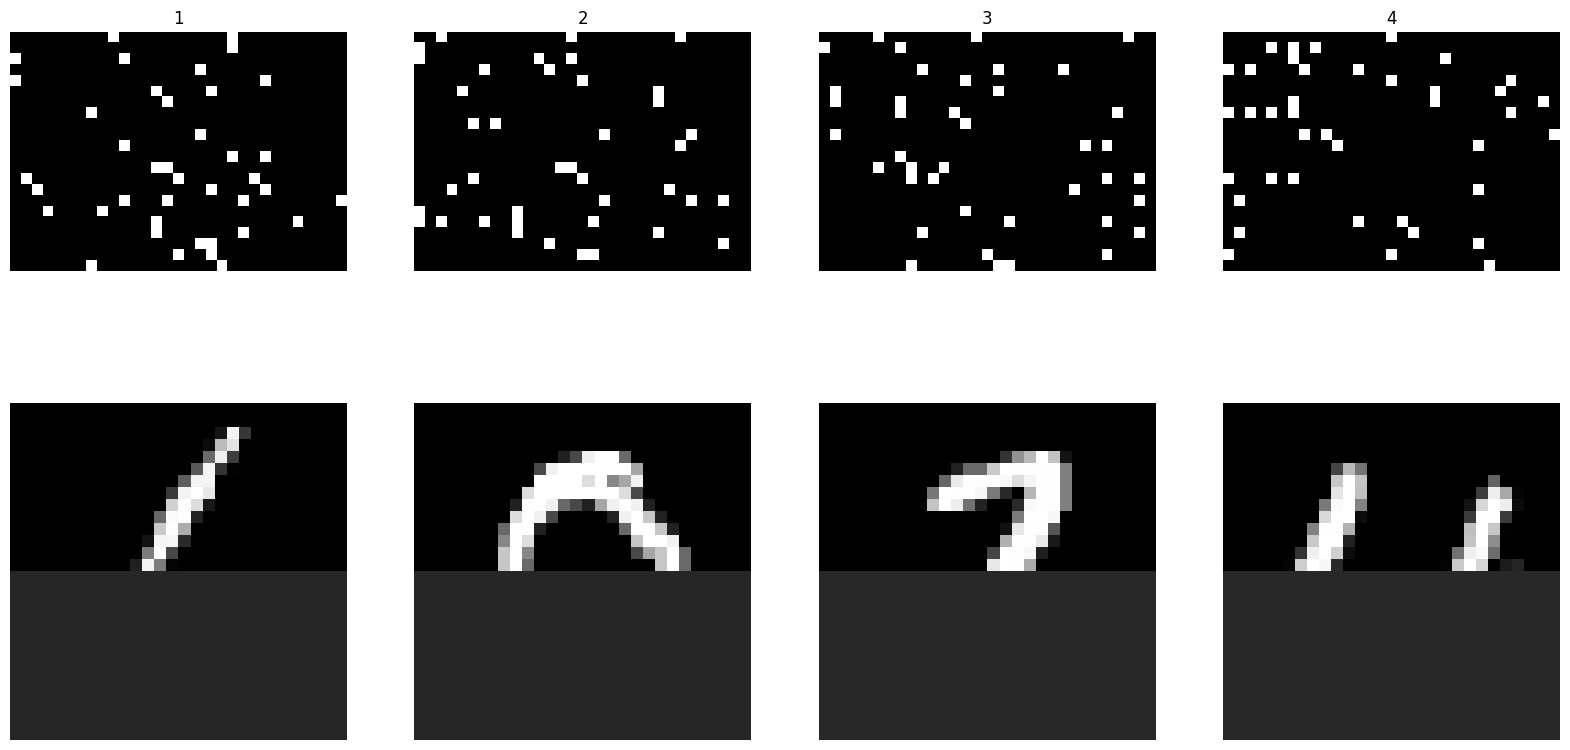

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i in range(4):
    axes[0, i].set_title(f'{i+1}')
    axes[0, i].imshow(ca3_half_patterns[str(i+1)], cmap="Greys_r")
    axes[1, i].imshow(img_half[i].view(size[1], size[2]).cpu(), cmap="Greys_r")    
    axes[0, i].axis('off')
    axes[1, i].axis('off')

(array([672.,   7.,   7.,  14.,  12.,   9.,  15.,   6.,   8.,  34.]),
 array([-0.42421296, -0.09964299,  0.22492698,  0.54949701,  0.87406695,
         1.19863689,  1.52320695,  1.84777689,  2.17234683,  2.49691677,
         2.82148671]),
 <BarContainer object of 10 artists>)

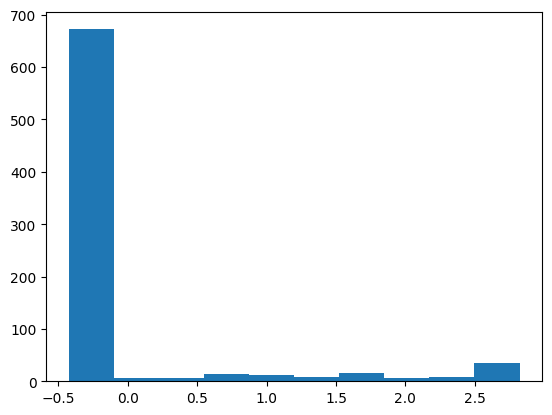

In [35]:
plt.hist(img[0])

In [36]:
(0-0.137)/0.3181

-0.4306821754165357

C:\Users\lucfonta\.git\static-hpc\src\hpc\models.py:185: RuntimeWarning: invalid value encountered in divide
  return np.dot(self.flattened_patterns, self.state) / (


6.2% of the memory patterns are unstable. These are ['3', '22', '34', '43']
n_steps: 50


C:\Users\lucfonta\.git\static-hpc\src\hpc\models.py:185: RuntimeWarning: invalid value encountered in divide
  return np.dot(self.flattened_patterns, self.state) / (


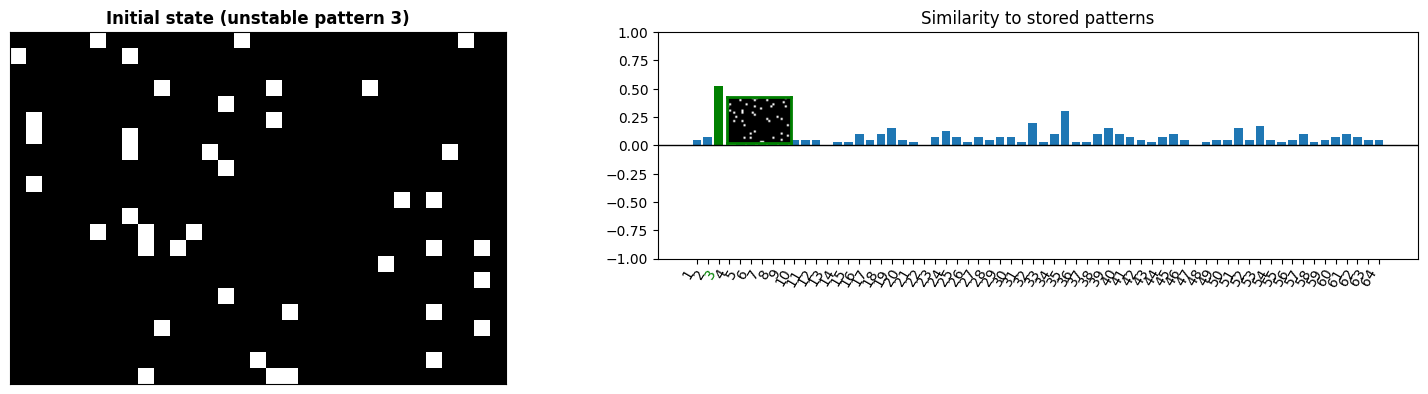

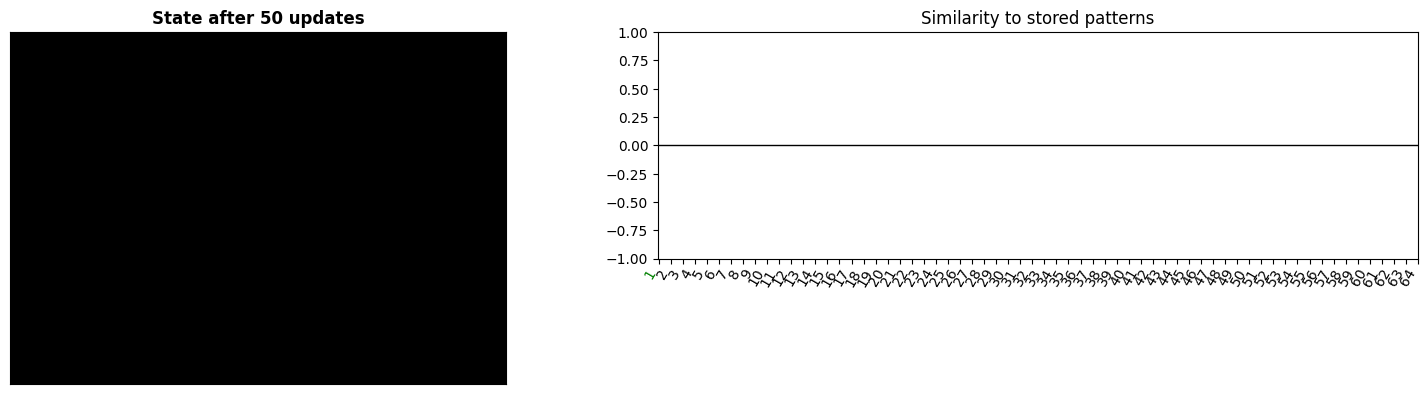

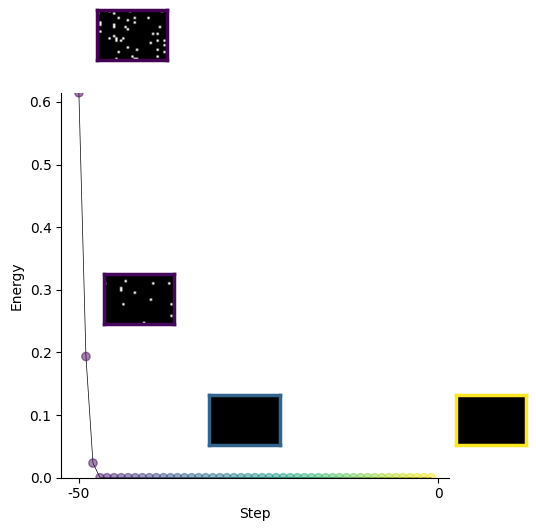

In [53]:
pcn.utils.seed(0)
# test ALL the memories and set which ones do not converge to the original memories (unstable patterns)
unstable_patterns = []
for pattern in ca3_half_patterns:
    HFN.set_state(ca3_half_patterns[pattern].flatten())
    for i in range(50):
        HFN.update_state(asynchronous=False)
    if not np.all(ca3_patterns[pattern].flatten() == HFN.state): #if a pattern is not stable, add it to the list
        unstable_patterns.append(pattern)

print(f"{100*len(unstable_patterns)/len(ca3_patterns):.1f}% of the memory patterns are unstable. These are {unstable_patterns}")

#visualise an unstable memory
if len(unstable_patterns) > 0:
    HFN.set_state(ca3_half_patterns[unstable_patterns[0]].flatten()) #reinitialise the state of the network
    HFN.visualise(title=f"Initial state (unstable pattern {unstable_patterns[0]})")
    for i in range(50):
        HFN.update_state(asynchronous=False)
    HFN.visualise(title=f"State after {i+1} updates")
    fig, ax = HFN.plot_energy(n_steps=50)

n_steps: 50


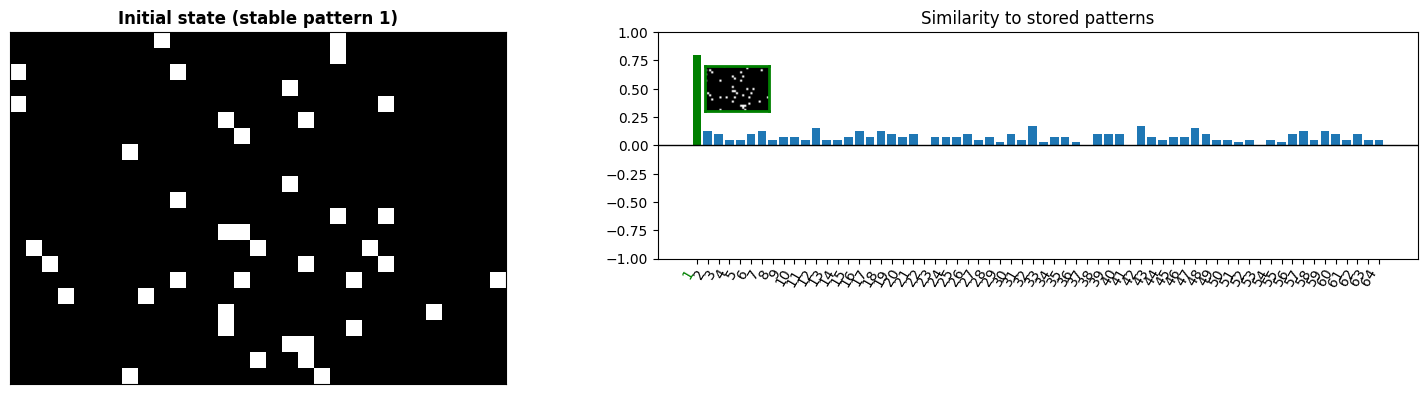

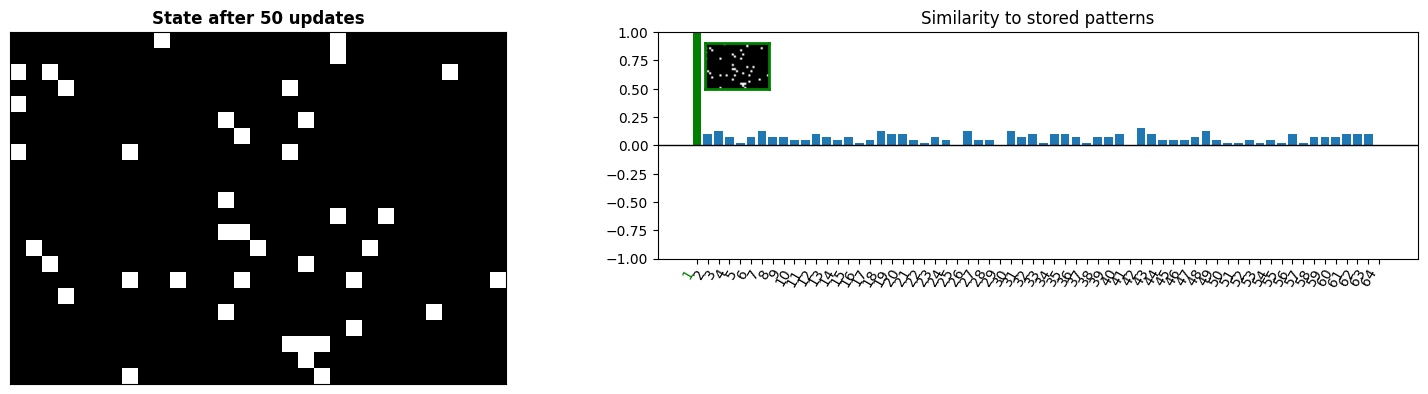

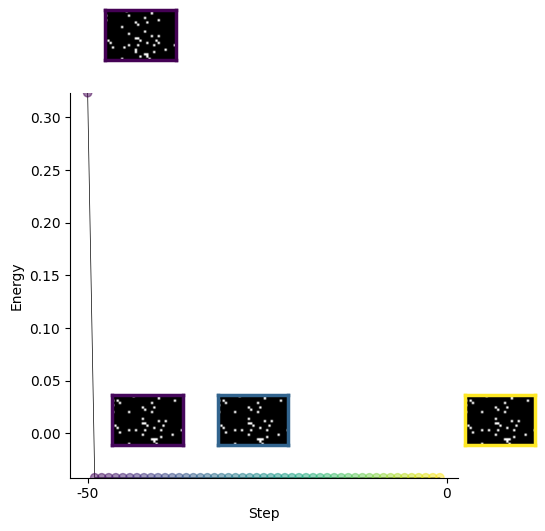

In [55]:
 # visualize a stable memory
stable_pattern = '1'
HFN.set_state(ca3_half_patterns[stable_pattern].flatten()) #reinitialise the state of the network
HFN.visualise(title=f"Initial state (stable pattern {stable_pattern})")
for i in range(50):
    HFN.update_state(asynchronous=False)
HFN.visualise(title=f"State after {i+1} updates")
fig, ax = HFN.plot_energy(n_steps=50)

In [11]:
HFN.theta_opt/(HFN.p*( 1- HFN.p)**2)

np.float32(0.46815988)

In [108]:
(HFN.N_neurons - 1)/HFN.N_neurons * (HFN.p**2 - 3/2*HFN.p + 0.5)/(1 - HFN.p)**2

np.float32(0.46815985)

In [12]:
alpha = HFN.N_patterns/HFN.N_neurons
alpha*HFN.p**2*(1 - HFN.p)

np.float32(0.00032286905)

## CA3-CA1

In [58]:
net = AutoEncoder(num_features=n_ec, latent_features=n_ca1, k=round(n_ca1*0.25))
net.load_state_dict(torch.load(f'models/k-sparse_AE_{dataset_name}.pt', weights_only=True))

<All keys matched successfully>

In [59]:
with torch.no_grad():
    outputs = net(ec)
    ca1 = outputs['z']

In [60]:
ca1.shape

torch.Size([64, 1064])

In [61]:
ec_train = train_dataset['ec']
with torch.no_grad():
    dg_train = EC_DG(ec_train)
    ca3_train = DG_CA3(dg_train)

In [62]:
ca3_mean = ca3_train.mean(dim=0)

### Training

In [63]:
pcn.utils.seed(0)
g = torch.Generator()
g.manual_seed(0)
tensor_dataset = TensorDataset(ca3, ca1)
train_loader = DataLoader(
    tensor_dataset, 
    batch_size=1, 
    shuffle=True, 
    worker_init_fn=pcn.utils.seed_worker, 
    generator=g
)

pcn.utils.seed(0)
g = torch.Generator()
g.manual_seed(0)
test_loader = DataLoader(
    tensor_dataset, 
    batch_size=1, 
    shuffle=True, 
    worker_init_fn=pcn.utils.seed_worker, 
    generator=g # same order as for train_loader
)  

(array([6.8639e+04, 2.2960e+03, 7.0300e+02, 3.2600e+02, 1.7600e+02,
        1.1200e+02, 5.3000e+01, 2.4000e+01, 1.4000e+01, 9.0000e+00]),
 array([0.        , 0.04807914, 0.09615827, 0.14423741, 0.19231655,
        0.24039568, 0.28847483, 0.33655396, 0.38463309, 0.43271223,
        0.48079136]),
 <BarContainer object of 10 artists>)

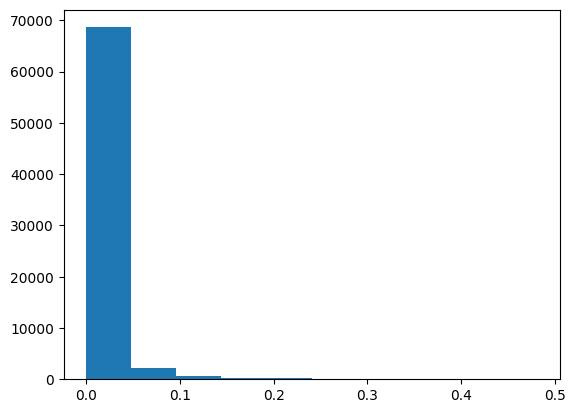

In [25]:
plt.hist(ca1.flatten())

In [64]:
lrs = sorted([2*i/10**(5-j) for i in range(1, 5) for j in range(5)])
n_seeds = 10
n_epochs = 10
errors = utils.best_lr(
    lrs=lrs, 
    train_loader=train_loader, 
    test_loader=test_loader, 
    in_size=n_ca3, 
    out_size=n_ca1,
    act_fn=torch.relu, 
    in_mean=ca3_mean, 
    use_bias=True, 
    f=0.25,
    glorot_init=False,
    n_epochs=n_epochs,
    n_seeds=n_seeds
)

100%|██████████| 10/10 [01:19<00:00,  7.96s/it]


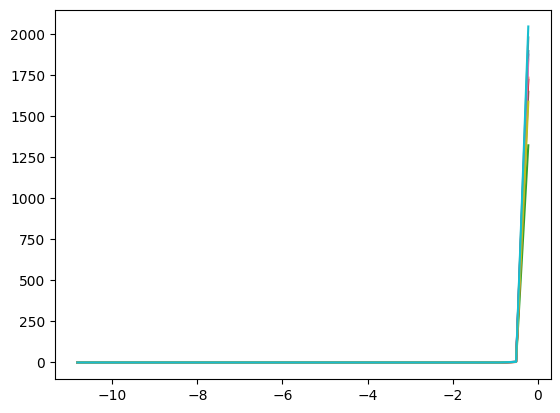

In [76]:
for seed in range(n_seeds):
    plt.plot(np.log(lrs), errors[seed])

In [65]:
mean_error = errors.mean(dim=0)
std_error = errors.std(dim=0, unbiased=False)

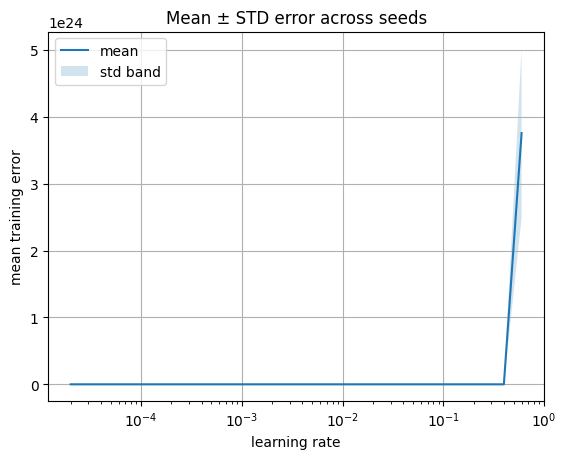

In [66]:
plt.plot(lrs, mean_error)
plt.fill_between(lrs, mean_error - std_error, mean_error + std_error, alpha=0.2)
plt.xscale('log')
plt.xlabel('learning rate')
plt.ylabel('mean training error')
plt.title('Mean ± STD error across seeds')
plt.grid(True)
plt.legend(['mean', 'std band'])

In [48]:
lrs = sorted([2*i/10**(5-j) for i in range(1, 5) for j in range(5)])
lrs

[2e-05,
 4e-05,
 6e-05,
 8e-05,
 0.0002,
 0.0004,
 0.0006,
 0.0008,
 0.002,
 0.004,
 0.006,
 0.008,
 0.02,
 0.04,
 0.06,
 0.08,
 0.2,
 0.4,
 0.6,
 0.8]

In [67]:
i = mean_error.argmin()
lr = lrs[i]
print(lr, mean_error[i])

0.04 tensor(1.1085e-05)


In [54]:
errors

tensor([[3.4883e-02, 3.4743e-02, 3.4550e-02, 3.4304e-02, 3.3678e-02, 3.2455e-02,
         3.0678e-02, 2.8597e-02, 2.3835e-02, 1.6735e-02, 1.0067e-02, 5.2346e-03,
         1.0200e-03, 5.7112e-04, 6.3449e-04, 1.3074e-03, 1.4051e-02, 1.9620e-01,
         4.7462e+01, 4.0300e+05],
        [3.4048e-02, 3.3924e-02, 3.3729e-02, 3.3492e-02, 3.2914e-02, 3.1736e-02,
         3.0058e-02, 2.7946e-02, 2.3387e-02, 1.6511e-02, 9.9782e-03, 5.1509e-03,
         9.9271e-04, 5.5716e-04, 6.3118e-04, 1.3882e-03, 1.3962e-02, 2.0935e-01,
         7.4535e+01, 4.6045e+05],
        [3.5151e-02, 3.5012e-02, 3.4813e-02, 3.4571e-02, 3.3953e-02, 3.2701e-02,
         3.0941e-02, 2.8715e-02, 2.4060e-02, 1.6940e-02, 1.0232e-02, 5.3220e-03,
         1.0296e-03, 5.7256e-04, 6.8947e-04, 1.4249e-03, 1.6648e-02, 1.9167e-01,
         4.7989e+01, 2.3149e+05],
        [3.5187e-02, 3.5059e-02, 3.4853e-02, 3.4580e-02, 3.3925e-02, 3.2707e-02,
         3.1023e-02, 2.8933e-02, 2.4288e-02, 1.7227e-02, 1.0354e-02, 5.4062e-03,
       

In [53]:
mean_error

tensor([3.4777e-02, 3.4648e-02, 3.4455e-02, 3.4204e-02, 3.3582e-02, 3.2359e-02,
        3.0619e-02, 2.8486e-02, 2.3848e-02, 1.6813e-02, 1.0132e-02, 5.2709e-03,
        1.0215e-03, 5.7552e-04, 6.4566e-04, 1.3681e-03, 1.4755e-02, 2.0415e-01,
        5.2541e+01, 3.5339e+05])

In [68]:
model = PatternAssociator(
    in_size=n_ca3, 
    in_mean=ca3_mean,
    out_size=n_ca1, 
    act_fn=torch.relu, 
    use_bias=True, 
    c=1, 
    f=0.25, 
    glorot_init=False
)
lr = 0.04
optimizer = pcn.optim.get_optim(
            [model.layer],
            "SGD",
            lr,
            batch_scale=True,
            grad_clip=None,
            weight_decay=None
        )
trainer = PATrainer(model, optimizer)

Epoch 1/10
All patterns: 0.3476
Last 20 patterns: 0.3540
Epoch 2/10
All patterns: 0.6592
Last 20 patterns: 0.6511
Epoch 3/10
All patterns: 0.8455
Last 20 patterns: 0.8483
Epoch 4/10
All patterns: 0.9105
Last 20 patterns: 0.9083
Epoch 5/10
All patterns: 0.9403
Last 20 patterns: 0.9406
Epoch 6/10
All patterns: 0.9560
Last 20 patterns: 0.9581
Epoch 7/10
All patterns: 0.9660
Last 20 patterns: 0.9654
Epoch 8/10
All patterns: 0.9728
Last 20 patterns: 0.9740
Epoch 9/10
All patterns: 0.9778
Last 20 patterns: 0.9780
Epoch 10/10
All patterns: 0.9818
Last 20 patterns: 0.9804


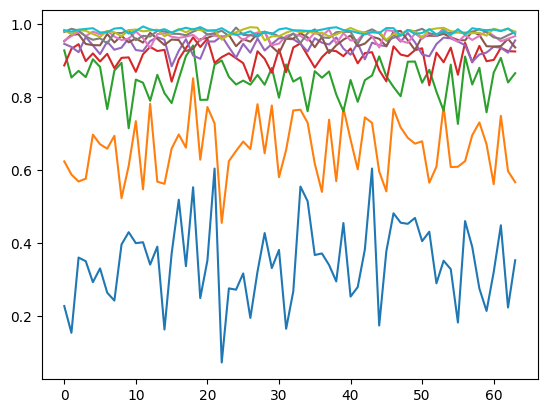

In [69]:
n_epochs = 10
with torch.no_grad():
    for epoch in range(n_epochs):
        corr = []
        print(f"Epoch {epoch+1}/{n_epochs}")
        trainer.train(train_loader, epoch)
        for inputs, targets in test_loader:
            inputs = pcn.utils.set_tensor(inputs)
            preds = model(inputs)
            corr.append(stats.pearsonr(preds.cpu().squeeze().numpy(), targets.squeeze().numpy())[0])
        plt.plot(corr)
        print(f"All patterns: {np.mean(corr):.4f}")
        print(f"Last 20 patterns: {np.mean(corr[-20:]):.4f}")

In [83]:
ec_train.mean(dim=0)

tensor([ 8.6027e-04, -3.8092e-03, -2.5876e-03, -1.8947e-03,  3.9458e-03,
        -6.5715e-03,  9.2401e-03,  2.1164e-03,  1.5340e-04, -4.8176e-03,
        -4.1165e-03, -4.8412e-03, -3.0363e-03, -3.4256e-03, -2.5447e-03,
         4.0127e-03, -5.4389e-03,  7.6699e-03,  1.0294e-02, -4.1979e-03,
         1.4218e-03, -5.0355e-03,  2.1309e-03, -1.3032e-03,  5.9120e-03,
        -5.4900e-03, -2.6295e-03,  8.0913e-03, -6.1038e-03,  5.0698e-05,
         5.7018e-03,  4.7994e-03, -1.7492e-03, -5.9030e-04, -6.0230e-03,
        -3.3674e-04,  7.4724e-03, -1.4059e-03, -3.8061e-03,  3.8089e-03,
        -1.1727e-03, -7.8468e-04,  4.5852e-03, -5.6988e-03,  1.1404e-02,
         2.0433e-03, -3.1883e-03,  3.0727e-03,  4.8941e-03,  7.2008e-04,
         8.0124e-03,  3.3927e-03, -3.0957e-03,  1.1520e-03, -7.2900e-03,
        -2.2205e-03, -7.7503e-03,  3.8389e-03,  1.5316e-02,  1.9994e-03,
         8.5588e-03, -4.3910e-03, -8.9602e-03, -4.2816e-03, -4.3220e-03,
        -2.4712e-03, -8.8247e-06, -6.8423e-04,  7.1

In [70]:
torch.save(model.state_dict(), f'models/CA3_CA1_{dataset_name}.pt')

### Recall

In [71]:
model = PatternAssociator(
    in_size=n_ca3, 
    in_mean=ca3_mean,
    out_size=n_ca1, 
    act_fn=torch.relu, 
    use_bias=True, 
    c=1, 
    f=0.25, 
    glorot_init=False
)
model.load_state_dict(torch.load(f'models/CA3_CA1_{dataset_name}.pt', weights_only=True))

<All keys matched successfully>

In [72]:
ca1_preds = torch.zeros((N_patterns, n_ca1))
with torch.no_grad():
    for i in range(N_patterns):
        inputs = ca3[i].unsqueeze(0)
        inputs = pcn.utils.set_tensor(inputs)
        ca1_preds[i] = model(inputs)

Mean CA1 correlation: 0.9818


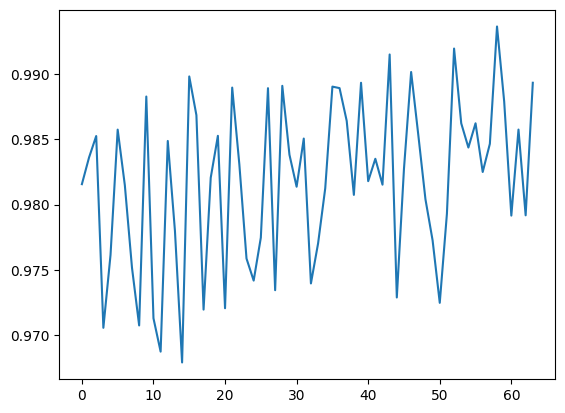

In [73]:
corr = [stats.pearsonr(ca1_preds[i].cpu().squeeze().numpy(), ca1[i].squeeze().numpy())[0] for i in range(N_patterns)]
plt.plot(corr)
print(f"Mean CA1 correlation: {np.mean(corr):.4f}")

## CA1-EC

In [74]:
with torch.no_grad():
    ec_preds = torch.tanh(net.decoder(ca1_preds))

In [75]:
ec_preds.shape

torch.Size([64, 300])

Mean EC correlation: 0.8803


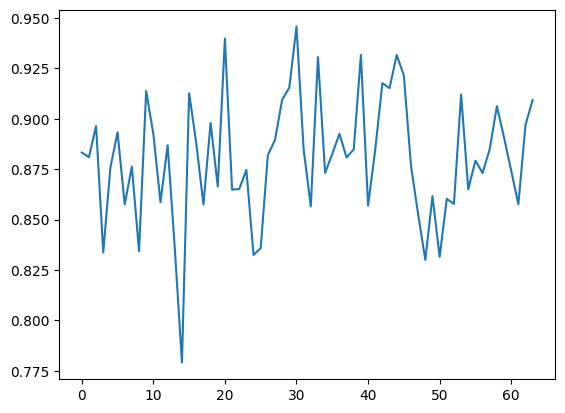

In [76]:
corr = [stats.pearsonr(ec_preds[i].cpu().squeeze().numpy(), ec[i].squeeze().numpy())[0] for i in range(N_patterns)]
plt.plot(corr)
print(f"Mean EC correlation: {np.mean(corr):.4f}")

In [77]:
with torch.no_grad():
    ec_preds = pcn.utils.set_tensor(ec_preds)
    pcmodel.replay_batch(
        ec_preds,
        n_max_iters,
        step_tolerance=step_tolerance,
        init_std=init_std,
        fixed_preds=fixed_preds_test
    )
    img_preds = pcmodel.preds[-1]    

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8214867].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9636924..5.766195].


Text(0.5, 1.0, 'Replayed image')

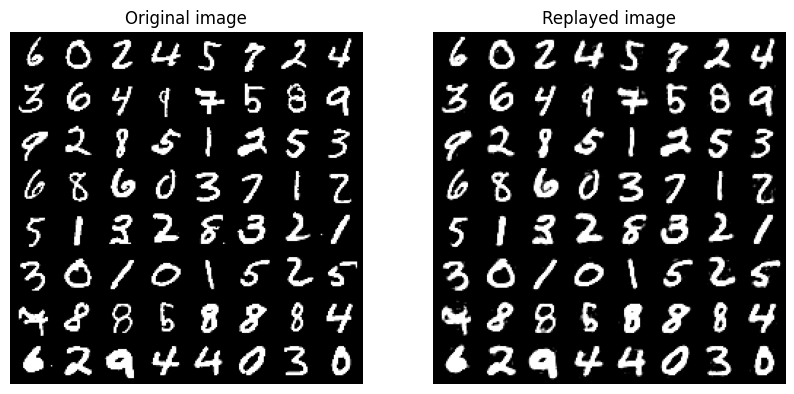

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plotting.plot_samples(axes[0], img)
plotting.plot_samples(axes[1], img_preds, size)
axes[0].set_title("Original image")
axes[1].set_title("Replayed image")

Mean image correlation: 0.9558


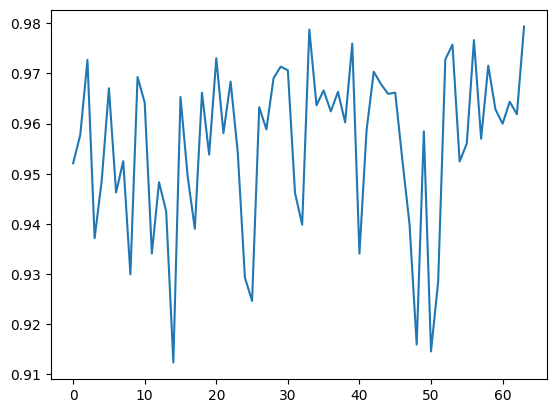

In [79]:
corr = [stats.pearsonr(img[i].cpu().squeeze().numpy(), img_preds[i].cpu().squeeze().numpy())[0] for i in range(N_patterns)]
plt.plot(corr)
print(f"Mean image correlation: {np.mean(corr):.4f}")

## EC-CA3-CA1-EC

In [81]:
ca3.shape

torch.Size([64, 682])

In [82]:
ca3_half_patterns

{'1': array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
         0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,

In [86]:
pcn.utils.seed(0)
ca3_recall = torch.zeros_like(ca3)
for pattern in ca3_half_patterns:
    HFN.set_state(ca3_half_patterns[pattern].flatten())
    for i in range(50):
        HFN.update_state(asynchronous=False)
    ca3_recall[int(pattern)-1] = torch.from_numpy(HFN.state)

C:\Users\lucfonta\.git\static-hpc\src\hpc\models.py:185: RuntimeWarning: invalid value encountered in divide
  return np.dot(self.flattened_patterns, self.state) / (


In [87]:
ca1_recall = torch.zeros((N_patterns, n_ca1))
with torch.no_grad():
    for i in range(N_patterns):
        inputs = ca3_recall[i].unsqueeze(0)
        inputs = pcn.utils.set_tensor(inputs)
        ca1_recall[i] = model(inputs)

In [88]:
with torch.no_grad():
    ec_recall = torch.tanh(net.decoder(ca1_recall))

In [90]:
with torch.no_grad():
    ec_recall = pcn.utils.set_tensor(ec_recall)
    pcmodel.replay_batch(
        ec_recall,
        n_max_iters,
        step_tolerance=step_tolerance,
        init_std=init_std,
        fixed_preds=fixed_preds_test
    )
    img_recall = pcmodel.preds[-1]   

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8214867].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.963693..5.766195].


Text(0.5, 1.0, 'Recalled image')

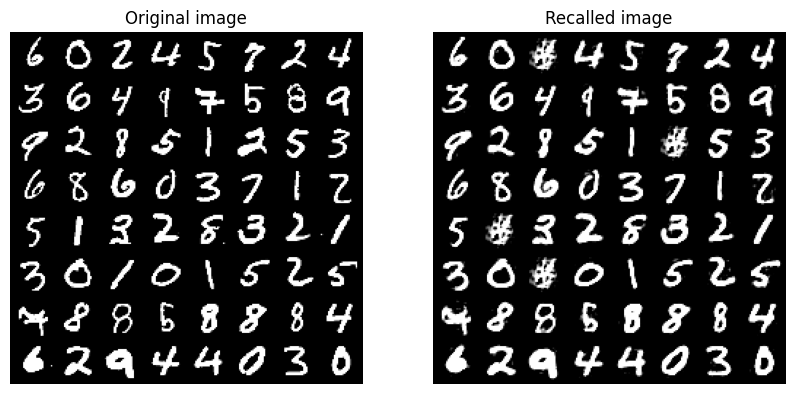

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plotting.plot_samples(axes[0], img)
plotting.plot_samples(axes[1], img_recall, size)
axes[0].set_title("Original image")
axes[1].set_title("Recalled image")